# 09 — Training a Softmax Linear Classifier with SGD

We now have all components required for learning: a score function, a scalar loss, and analytic gradients. This notebook combines them in a minibatch stochastic-gradient-descent loop and trains a linear classifier on CIFAR-10.

## Learning objectives

- interpret a gradient-descent parameter update;
- distinguish full-batch, stochastic, and minibatch gradient descent;
- sample minibatches without changing the train/validation split;
- implement a reusable vanilla-SGD training loop;
- monitor loss and train/validation accuracy;
- observe how learning rate changes optimization behavior;
- visualize learned linear-classifier weight templates.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

## 1. What a gradient update means

For parameters $W$ and learning rate $\eta$, gradient descent performs

$$W \leftarrow W-\eta\frac{\partial L}{\partial W}.$$

The gradient points in the direction of fastest local increase in loss, so subtracting it moves toward lower loss. The learning rate $\eta$ controls step size:

- too small: progress is reliable but slow;
- suitable: loss decreases efficiently;
- too large: updates may overshoot, oscillate, or diverge.

The gradient is a local slope, not a command to replace the parameter with the gradient.

### Exercise 1 — Perform one update

Let `w = 2.0`, `dw = 0.5`, and learning rate `0.1`. Calculate the new weight using gradient descent. Then repeat with `dw = -0.5` and explain why the update direction reverses.

In [16]:
w = 2.0
learning_rate_example = 0.1

w_after_positive_gradient = w - learning_rate_example * 0.5
w_after_negative_gradient = w - learning_rate_example * -0.5

assert np.isclose(w_after_positive_gradient, 1.95)
assert np.isclose(w_after_negative_gradient, 2.05)
print(w_after_positive_gradient, w_after_negative_gradient)

1.95 2.05


update direction reverses cause gradient value is positive in one case and negative in another

## 2. Full-batch, stochastic, and minibatch gradients

- **Full-batch gradient descent** computes a gradient using every training example before each update. It is accurate for the current parameters but expensive.
- **Stochastic gradient descent (strict meaning)** uses one randomly selected example per update. It is cheap but very noisy.
- **Minibatch SGD** uses a small random subset. It balances computational efficiency, vectorization, and gradient noise. In practice, the name SGD usually includes this minibatch version.

A minibatch gradient is an estimate of the full training gradient. Individual updates may increase full-dataset loss even when the longer-term trend improves.

## 3. Prepare CIFAR-10 train and validation data

We create the split before training and never sample validation examples into minibatches. The feature mean is computed from training data only, then applied to both splits. This avoids validation-data leakage.

The default subset sizes keep this practice responsive. They can be increased later without changing the implementation.

In [17]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
labels_all = np.asarray(dataset.targets, dtype=np.int64)

TRAIN_SIZE = 10_000
VAL_SIZE = 2_000
split_rng = np.random.default_rng(SEED)
permutation = split_rng.permutation(len(dataset.data))
train_indices = permutation[:TRAIN_SIZE]
val_indices = permutation[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

X_train = dataset.data[train_indices].reshape(TRAIN_SIZE, -1).astype(np.float32) / 255.0
y_train = labels_all[train_indices]
X_val = dataset.data[val_indices].reshape(VAL_SIZE, -1).astype(np.float32) / 255.0
y_val = labels_all[val_indices]

train_mean = X_train.mean(axis=0, keepdims=True)
X_train -= train_mean
X_val -= train_mean

assert len(np.intersect1d(train_indices, val_indices)) == 0
assert X_train.shape == (TRAIN_SIZE, 32 * 32 * 3)
assert X_val.shape == (VAL_SIZE, 32 * 32 * 3)
print("Train shapes:", X_train.shape, y_train.shape)
print("Validation shapes:", X_val.shape, y_val.shape)
print("Mean absolute centered train feature:", np.abs(X_train.mean(axis=0)).mean())

Train shapes: (10000, 3072) (10000,)
Validation shapes: (2000, 3072) (2000,)
Mean absolute centered train feature: 8.651664e-07


### Exercise 2 — Sample a minibatch

Implement a helper that returns corresponding rows from `X` and `y`. Sample indices uniformly without replacement. Use the provided generator rather than global random state so experiments can be reproduced.

In [18]:
def sample_minibatch(
    X: np.ndarray, y: np.ndarray, batch_size: int, generator: np.random.Generator
) -> tuple[np.ndarray, np.ndarray]:
    """Sample corresponding feature and label rows without replacement."""
    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must have the same number of examples.")
    if not isinstance(batch_size, (int, np.integer)) or batch_size <= 0:
        raise ValueError("batch_size must be a positive integer.")
    if batch_size > X.shape[0]:
        raise ValueError("batch_size cannot exceed the dataset size.")

    # sample row indices and return matching X and y rows.
    indices = generator.choice(X.shape[0], size=batch_size, replace=False)
    return X[indices], y[indices]


batch_rng = np.random.default_rng(SEED)
X_batch, y_batch = sample_minibatch(X_train, y_train, 128, batch_rng)
assert X_batch.shape == (128, X_train.shape[1])
assert y_batch.shape == (128,)
print(X_batch.shape, y_batch.shape)

(128, 3072) (128,)


## 4. Softmax loss and gradient

This is the function derived and gradient-checked in [notebook 08](./08_softmax_gradient_checking.ipynb). It is provided here so this notebook can concentrate on optimization. Shapes follow the project convention: `X (N, D)`, `W (C, D)`, `b (C,)`.

In [19]:
def softmax_loss_and_gradient(
    X: np.ndarray,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    regularization_strength: float = 0.0,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Return stable softmax loss and gradients for class-major weights."""
    scores = X @ W.T + b
    shifted_scores = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted_scores)
    sum_exp_scores = exp_scores.sum(axis=1, keepdims=True)
    probabilities = exp_scores / sum_exp_scores

    correct_scores = shifted_scores[np.arange(X.shape[0]), y]
    data_loss = np.mean(np.log(sum_exp_scores[:, 0]) - correct_scores)
    regularization_loss = regularization_strength * np.sum(W * W)

    d_scores = probabilities.copy()
    d_scores[np.arange(X.shape[0]), y] -= 1.0
    d_scores /= X.shape[0]
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)
    return float(data_loss + regularization_loss), dW, db

### Exercise 3 — Initialize parameters and check initial loss

Create small random weights and zero biases. On a minibatch, the initial data loss should be near $\log(10)$. Include regularization in the function call but separately reason why its initial contribution is small.

In [20]:
num_classes = len(CLASS_NAMES)
num_features = X_train.shape[1]
initialization_rng = np.random.default_rng(SEED)

W_initial = initialization_rng.normal(loc=0.0, scale=0.01, size=(num_classes, num_features))
b_initial = np.zeros(num_classes)
regularization_strength = 1e-3

initial_loss, initial_dW, initial_db = softmax_loss_and_gradient(
    X_batch, y_batch, W_initial, b_initial, regularization_strength
)
assert W_initial.shape == (num_classes, num_features)
assert b_initial.shape == (num_classes,)
assert np.isclose(initial_loss, np.log(num_classes), atol=0.05)
print("Initial loss:", initial_loss)
print("log(C):", np.log(num_classes))
print("Gradient norms:", np.linalg.norm(initial_dW), np.linalg.norm(initial_db))

Initial loss: 2.327749097956974
log(C): 2.302585092994046
Gradient norms: 1.5396238240766187 0.07604965927600224


## 5. Implement minibatch SGD

Each iteration performs four operations:

1. sample a minibatch;
2. calculate its loss and gradients;
3. update parameters in the negative-gradient direction;
4. record loss for diagnosis.

The minibatch loss will fluctuate. Look for a downward trend rather than requiring every iteration to improve.

### Exercise 4 — Complete the training loop

In [21]:
def train_softmax_sgd(
    X: np.ndarray,
    y: np.ndarray,
    W_start: np.ndarray,
    b_start: np.ndarray,
    *,
    learning_rate: float,
    regularization_strength: float,
    batch_size: int,
    num_iterations: int,
    generator: np.random.Generator,
    verbose_every: int | None = None,
) -> tuple[np.ndarray, np.ndarray, list[float]]:
    """Train a softmax linear classifier with vanilla minibatch SGD."""
    if learning_rate <= 0 or regularization_strength < 0:
        raise ValueError("Learning rate must be positive and regularization nonnegative.")
    if num_iterations <= 0:
        raise ValueError("num_iterations must be positive.")

    W = W_start.copy()
    b = b_start.copy()
    loss_history: list[float] = []

    for iteration in range(num_iterations):
        # sample a minibatch.
        minibatch_X, minibatch_y = sample_minibatch(X, y, batch_size, generator)
        # compute loss, dW, and db.
        loss, dW, db = softmax_loss_and_gradient(
            minibatch_X, minibatch_y, W, b, regularization_strength
        )
        # update W and b with vanilla SGD.
        W -= learning_rate * dW
        b -= learning_rate * db
        # append the loss and optionally print progress.
        loss_history.append(loss)
        if verbose_every is not None and iteration % verbose_every == 0:
            print(f"Iteration {iteration}, Loss: {loss}")

    return W, b, loss_history

In [22]:
training_rng = np.random.default_rng(SEED + 1)
W_trained, b_trained, loss_history = train_softmax_sgd(
    X_train,
    y_train,
    W_initial,
    b_initial,
    learning_rate=0.1,
    regularization_strength=regularization_strength,
    batch_size=256,
    num_iterations=500,
    generator=training_rng,
    verbose_every=100,
)
assert len(loss_history) == 500
assert np.all(np.isfinite(loss_history))
print("First 20 mean loss:", np.mean(loss_history[:20]))
print("Last 20 mean loss: ", np.mean(loss_history[-20:]))

Iteration 0, Loss: 2.315741661973486
Iteration 100, Loss: 1.7388615751115168
Iteration 200, Loss: 1.7742178419830785
Iteration 300, Loss: 1.7124439246743934
Iteration 400, Loss: 1.7428297238593846
First 20 mean loss: 2.0338937429640813
Last 20 mean loss:  1.6621010984046822


## 6. Diagnose the loss curve

Raw minibatch loss is noisy because each point uses different examples. A moving average makes the underlying trend easier to see without changing training itself.

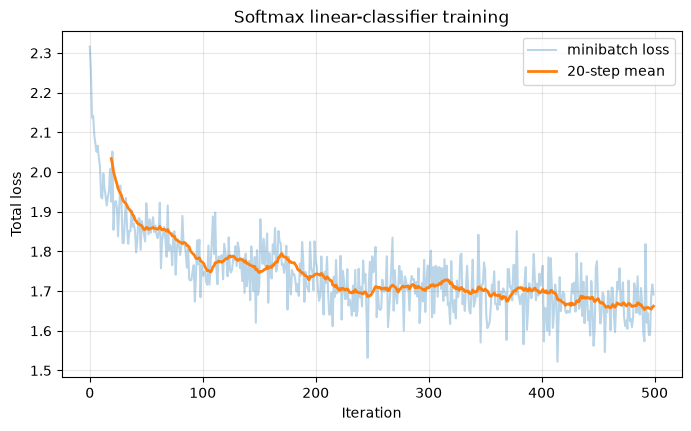

In [23]:
def moving_average(values: list[float], window: int) -> np.ndarray:
    values_array = np.asarray(values, dtype=np.float64)
    if window <= 0 or window > len(values_array):
        raise ValueError("window must be between 1 and the number of values.")
    kernel = np.ones(window) / window
    return np.convolve(values_array, kernel, mode="valid")


window = 20
smoothed_loss = moving_average(loss_history, window)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(loss_history, alpha=0.3, label="minibatch loss")
ax.plot(np.arange(window - 1, len(loss_history)), smoothed_loss, linewidth=2, label="20-step mean")
ax.set(xlabel="Iteration", ylabel="Total loss", title="Softmax linear-classifier training")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Measure train and validation accuracy

Accuracy uses `argmax` scores; softmax probabilities are unnecessary because softmax preserves score ordering. Validation accuracy estimates generalization and must not influence individual gradient updates.

### Exercise 5 — Implement prediction and accuracy

In [24]:
def predict_linear(X: np.ndarray, W: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Return the highest-scoring class for every example."""
    scores = X @ W.T + b
    return np.argmax(scores, axis=1)


def accuracy(X: np.ndarray, y: np.ndarray, W: np.ndarray, b: np.ndarray) -> float:
    """Return the fraction of correctly predicted labels."""
    predictions = predict_linear(X, W, b)
    return np.mean(predictions == y)


train_accuracy = accuracy(X_train, y_train, W_trained, b_trained)
val_accuracy = accuracy(X_val, y_val, W_trained, b_trained)
print(f"Training accuracy:   {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")
assert train_accuracy > 0.20
assert val_accuracy > 0.20

Training accuracy:   0.437
Validation accuracy: 0.407


## 8. Learning-rate experiment

A fair comparison starts each run from identical parameters and gives it an independently recreated generator with the same seed. This makes all runs see the same minibatch sequence, isolating learning rate as the controlled variable.

This is a small optimization experiment, not yet a hyperparameter search. We will use validation data systematically in a later notebook.

### Exercise 6 — Compare three learning rates

Train for 150 iterations with learning rates `0.01`, `0.1`, and `1.0`. Store each loss history and validation accuracy. Plot smoothed curves, then explain which rate makes the most useful progress under this fixed iteration budget.

lr=0.01: validation accuracy=0.324
lr=0.1 : validation accuracy=0.382
lr=1.0 : validation accuracy=0.265


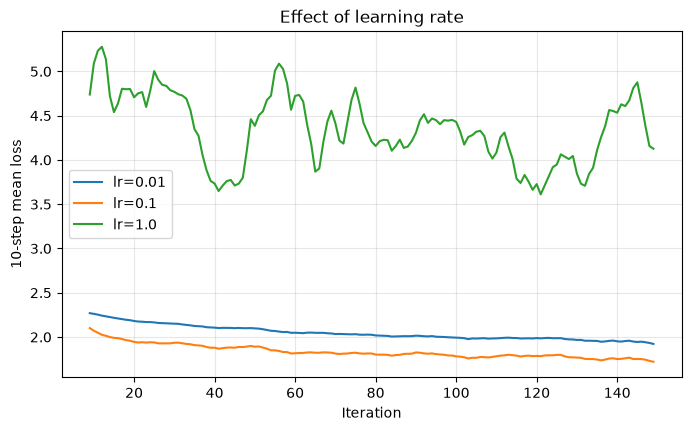

In [25]:
learning_rates = [0.01, 0.1, 1.0]
experiment_results = {}

# train one model per learning rate from the same W_initial and b_initial.
# Give every run np.random.default_rng(SEED + 2) for identical minibatches.
for learning_rate in learning_rates:
    training_rng = np.random.default_rng(SEED + 2)
    W_experimental, b_experimental, loss_history = train_softmax_sgd(
        X_train,
        y_train,
        W_initial,
        b_initial,
        learning_rate=learning_rate,
        regularization_strength=regularization_strength,
        batch_size=256,
        num_iterations=150,
        generator=training_rng,
    )
    val_accuracy = accuracy(X_val, y_val, W_experimental, b_experimental)
    experiment_results[learning_rate] = {
        "loss_history": loss_history,
        "val_accuracy": val_accuracy,
    }

fig, ax = plt.subplots(figsize=(8, 4.5))
for learning_rate, result in experiment_results.items():
    smoothed = moving_average(result["loss_history"], window=10)
    ax.plot(np.arange(9, len(result["loss_history"])), smoothed, label=f"lr={learning_rate}")
    print(f"lr={learning_rate:<4}: validation accuracy={result['val_accuracy']:.3f}")
ax.set(xlabel="Iteration", ylabel="10-step mean loss", title="Effect of learning rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 9. Visualize learned class templates

Each row of `W` contains one weight per input pixel channel for one class. Reshaping it to `(32, 32, 3)` reveals the linear template used for that class. Per-class display normalization improves visibility but means colors cannot be compared quantitatively between panels.

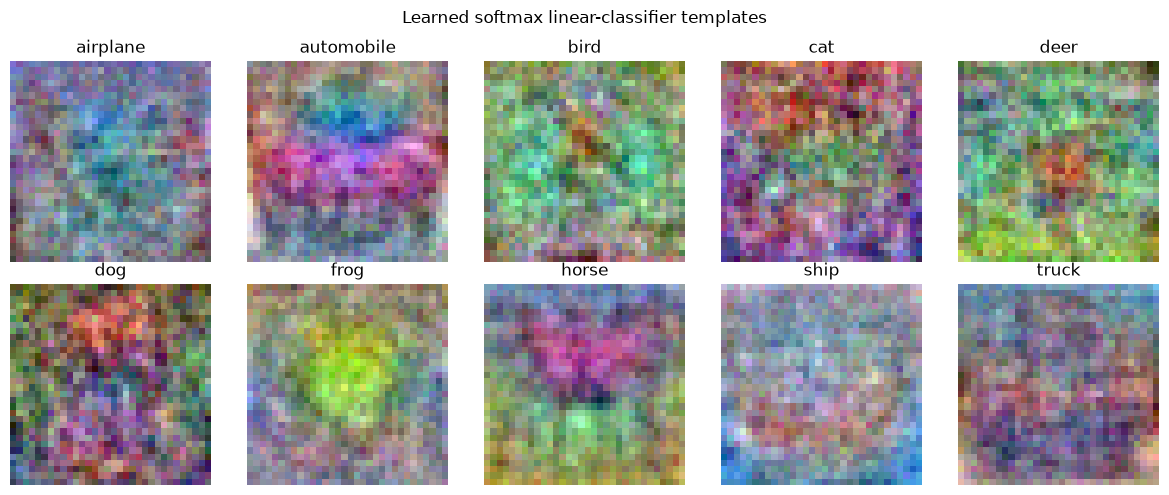

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_index, ax in enumerate(axes.flat):
    template = W_trained[class_index].reshape(32, 32, 3)
    display_template = template - template.min()
    display_template /= max(display_template.max(), 1e-12)
    ax.imshow(display_template)
    ax.set_title(CLASS_NAMES[class_index])
    ax.axis("off")
fig.suptitle("Learned softmax linear-classifier templates")
fig.tight_layout()
plt.show()

## Reflection

Add a Markdown cell answering:

1. Why do we subtract rather than add the gradient?
2. What role does the learning rate play?
3. Why is a minibatch gradient noisy, and why can that still be useful?
4. Why must validation examples be excluded from minibatch updates?
5. Why is the training mean applied to validation features rather than computing a separate validation mean?
6. Why can individual minibatch losses rise even during successful training?
7. What evidence shows that the model learned more than random guessing?
8. What does a train/validation accuracy gap suggest?
9. How did learning rate affect the loss curves?
10. What do the weight images reveal about the limitations of a linear classifier?

Next we will make the linear classifier reusable, compare SVM and softmax training, and select hyperparameters with validation or cross-validation.

1. We must move down the slope meaning if slope positive we move in opposite direction.
2. It defines how much parameters are change within one update.
3. Noisy because we take random subset samples from dataset. Usefull cause it is computational efficient and also might help avoid local minimum in some cases. 

A minibatch gradient is noisy because it estimates the full-dataset gradient using randomly selected examples. It is useful because it is cheaper, allows frequent updates, and its noise can sometimes help optimization explore the objective.

However, “avoiding local minima” is not especially relevant to this linear softmax classifier. Its data loss is convex in the linear parameters, and L2 regularization remains convex. There are no problematic non-global local minima here. That idea becomes more relevant for neural networks and other non-convex objectives.


4. To avoid data leackage
5. To avoids validation-data leakage. Computing a separate validation mean would make preprocessing depend on the evaluation dataset and would not match how a future individual input is processed.
6. Some batches might have better scores, some worse. The smaller minibatch the more noisy it mihgt become.
7. Accuracy about 40% for 10 class prediction is much higher than random guess 10%
8. A large train/validation gap can suggest overfitting.

A small gap does not automatically mean underfitting:
- high train and high validation accuracy with a small gap means good generalization;
- low train and low validation accuracy suggests underfitting;
- high train but much lower validation accuracy suggests overfitting.

Here the gap is only about three percentage points, while both accuracies are around 40%. That suggests limited model capacity more than severe overfitting.

9. Big learning rate might cause oscillation and divergence. Small means loss will decrease slower with each iteration.

0.01 learned steadily but too slowly for 150 iterations;
0.1 made the best useful progress;
1.0 took overly aggressive steps, yielding worse loss behavior and accuracy.

10. There is no way to consider non-linear affects and other:

- learns only one template per class;
- averages different poses, shapes, colors, and backgrounds;
- uses only a weighted sum of pixels;
- cannot learn nonlinear feature interactions;
- creates only linear decision boundaries;
- cannot build hierarchical features such as edges → textures → object parts.